<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">למה צריך CNN אם יש מודל רגרסיה מעולה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">כאשר סיימנו את אימון מודל הCNN וראינו       שאומנם הוא מציג ביצועים טובים מאוד הוא בכל זאת טועה. ומנגד מודל הרגרסיה שאימנו קודם לכן לא טעה                                                                                                 בכלל. אז החלטנו לערוך בינהם השוואה על סט הנתונים מהחלק הראשון בפרוייקט , סט זה לא השתתף באימון הנוכחי                                                                                                 ומבחינתינו מייצג תמונה בלתי תלויה של העולם האמיתי.</div>
</div>

In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from PIL import Image
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)


# Paths and device
OUTPUT_DIR = Path("passport_full_image_output")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOGISTIC_MODEL_FILE = OUTPUT_DIR / "full_page_logistic_baseline.joblib"
CNN_MODEL_FILE = OUTPUT_DIR / "full_page_cnn.keras"
CNN_SCALER_FILE = OUTPUT_DIR / "full_page_cnn_scaler.joblib"


# Load the two classifiers
logistic_model = joblib.load(LOGISTIC_MODEL_FILE)
cnn_model = tf.keras.models.load_model(CNN_MODEL_FILE)
cnn_scaler = joblib.load(CNN_SCALER_FILE)


# Load EfficientNet-B0 feature extractor
weights = EfficientNet_B0_Weights.DEFAULT
preprocess = weights.transforms()

encoder = efficientnet_b0(weights=weights)
encoder.classifier = nn.Identity()
encoder = encoder.to(DEVICE).eval()


def image_to_vector(image_path):
    """Convert one image to a 1,280-feature EfficientNet-B0 vector."""

    image = Image.open(image_path).convert("RGB")

    # Add white padding without changing the aspect ratio
    side = max(image.size)
    square = Image.new("RGB", (side, side), (255, 255, 255))

    x = (side - image.width) // 2
    y = (side - image.height) // 2
    square.paste(image, (x, y))

    # Prepare the image for EfficientNet
    image_tensor = preprocess(square).unsqueeze(0).to(DEVICE)

    # Extract the vector
    with torch.inference_mode():
        vector = encoder(image_tensor)

    return vector.cpu().numpy().astype(np.float32)


def predict_image(image_path, threshold=0.5):
    """Run both classifiers on one image."""

    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    # Shape: (1, 1280)
    vector = image_to_vector(image_path)

    # Logistic Regression
    logistic_probability = float(
        logistic_model.predict_proba(vector)[0, 1]
    )
    logistic_prediction = int(logistic_probability >= threshold)

    # CNN: normalization and channel dimension
    cnn_input = cnn_scaler.transform(vector).astype(np.float32)
    cnn_input = cnn_input[..., np.newaxis]  # (1, 1280, 1)

    cnn_probability = float(
        cnn_model.predict(cnn_input, verbose=0)[0, 0]
    )
    cnn_prediction = int(cnn_probability >= threshold)

    return pd.DataFrame({
        "model": ["Logistic Regression", "CNN"],
        "prediction": [
            "Passport" if logistic_prediction == 1 else "No passport",
            "Passport" if cnn_prediction == 1 else "No passport",
        ],
        "passport_probability": [
            logistic_probability,
            cnn_probability,
        ],
    })



C:\Users\user\PycharmProjects\Project.DS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">הרצה השוואתית</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">הרצנו את שני המודלים על סט נתונים בילתי                                        תלוי ומתוייג כאשר סף ההחלטה לשינהם הוא 0.5 ואנו שומרים גם                                                                                               את הסיווג הסופי של כל אחד וגם את הציון אותו כל אחד נתן.</div>
</div>

In [2]:
LABELS_FILE = Path("passport_vector_output/labels.csv")
IMAGES_DIR = Path("dataset_images")
OUTPUT_FILE = Path("passport_full_image_output/model_predictions.csv")

labels_df = pd.read_csv(LABELS_FILE, encoding="utf-8-sig")

predictions = []

for row in tqdm(
    labels_df.itertuples(index=False),
    total=len(labels_df),
    desc="Predicting images"
):
    relative_path = Path(row.relative_path)

    # Support both relative and absolute paths
    if relative_path.is_absolute():
        image_path = relative_path
    else:
        image_path = IMAGES_DIR / relative_path

    # Run both models
    result = predict_image(image_path).set_index("model")

    logistic_probability = result.loc[
        "Logistic Regression", "passport_probability"
    ]
    cnn_probability = result.loc[
        "CNN", "passport_probability"
    ]

    predictions.append({
        "relative_path": row.relative_path,
        "label": row.label,

        "logistic_prediction": int(
            logistic_probability >= 0.5
        ),
        "logistic_probability": logistic_probability,

        "cnn_prediction": int(
            cnn_probability >= 0.5
        ),
        "cnn_probability": cnn_probability,
    })


predictions_df = pd.DataFrame(predictions)

predictions_df.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("Saved predictions:", OUTPUT_FILE)
display(predictions_df.head())

Predicting images: 100%|██████████| 141/141 [00:52<00:00,  2.71it/s]

Saved predictions: passport_full_image_output\model_predictions.csv


,relative_path,label,logistic_prediction,logistic_probability,cnn_prediction,cnn_probability
0,PDF_Edge_Case_11_page_1.jpg,1,1,0.999999,1,0.954542
1,PDF_Edge_Case_12_page_1.jpg,0,0,0.000255,0,0.061834
2,PDF_Edge_Case_12_page_2.jpg,0,0,0.000572,0,0.363961
3,PDF_Edge_Case_12_page_3.jpg,1,1,1.000000,1,0.924062
4,PDF_Edge_Case_12_page_4.jpg,0,0,0.000141,0,0.346994


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">תוצאות ההשוואה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;"></div>
</div>

,class,count
0,No passport,110
1,Passport,31
2,Total,141


,model,accuracy,precision,recall,f1,roc_auc,correct_predictions,errors
0,Logistic Regression,0.9787,1.0,0.9032,0.9492,1.0,138,3
1,CNN,1.0000,1.0,1.0000,1.0000,1.0,141,0


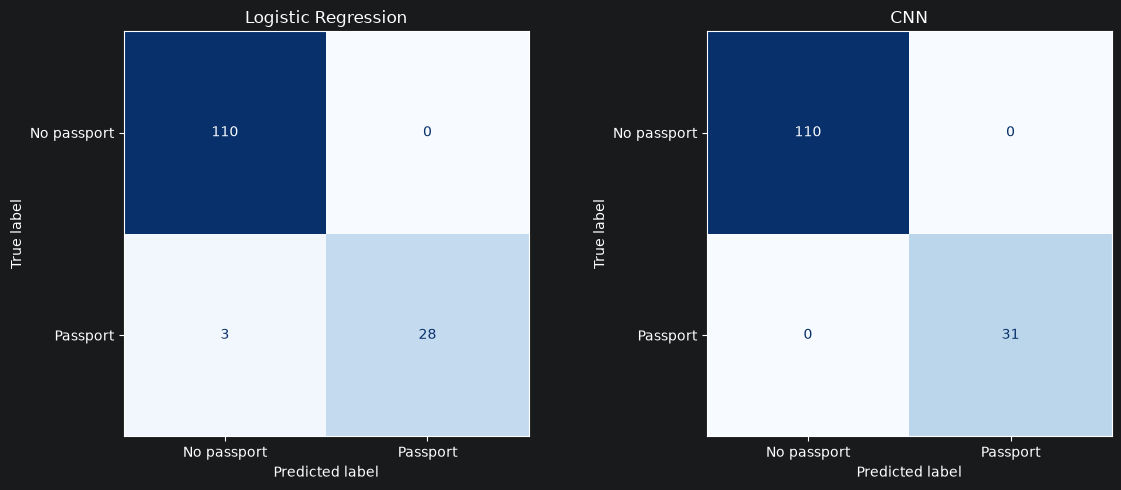

In [3]:
y_true = predictions_df["label"].astype(int)

models = {
    "Logistic Regression": {
        "prediction": "logistic_prediction",
        "probability": "logistic_probability",
    },
    "CNN": {
        "prediction": "cnn_prediction",
        "probability": "cnn_probability",
    },
}


# Dataset statistics
dataset_statistics = pd.DataFrame({
    "class": ["No passport", "Passport", "Total"],
    "count": [
        (y_true == 0).sum(),
        (y_true == 1).sum(),
        len(y_true),
    ],
})

display(dataset_statistics)


# Model statistics
statistics = []

for model_name, columns in models.items():
    y_prediction = predictions_df[
        columns["prediction"]
    ].astype(int)

    y_probability = predictions_df[
        columns["probability"]
    ].astype(float)

    statistics.append({
        "model": model_name,
        "accuracy": accuracy_score(
            y_true, y_prediction
        ),
        "precision": precision_score(
            y_true, y_prediction, zero_division=0
        ),
        "recall": recall_score(
            y_true, y_prediction, zero_division=0
        ),
        "f1": f1_score(
            y_true, y_prediction, zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true, y_probability
        ),
        "correct_predictions": (
            y_true == y_prediction
        ).sum(),
        "errors": (
            y_true != y_prediction
        ).sum(),
    })


statistics_df = pd.DataFrame(statistics).round(4)
display(statistics_df)


# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for axis, (model_name, columns) in zip(
    axes, models.items()
):
    y_prediction = predictions_df[
        columns["prediction"]
    ].astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_prediction,
        display_labels=["No passport", "Passport"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )

    axis.set_title(model_name)

plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">סיכום תוצאות</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">ניתן להבחין שמודל הCNN מציג ביצועים עדיפים על פני מודל הרגרסיה על נתונים חדשים אומנם לא בפער גדול אבל הנושא הזה העלה אצלינו מספר שאולות.</div>
</div>

In [4]:
def open_rgb(path):
    return Image.open(path).convert("RGB")

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">דוגמה ראשונה - סיווג זהה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">בחנו את התמונות שעליהן המודלים הציגו סיווג שונה וגם תמונות דומות אבל עם סיווג זהה בשני המודלים ועלינו על מסכנות מעניינות. נתחיל מלבחון את                                                                                                התמונה                                                                                                   מטה ונראה שלתמונה המכילה דרכון צבעוני בראש העמוד מודל הרגרסיה נתן לה ציון גבוהה במיוחד.</div>
</div>

,model,prediction,passport_probability
0,Logistic Regression,Passport,0.973436
1,CNN,Passport,0.790451


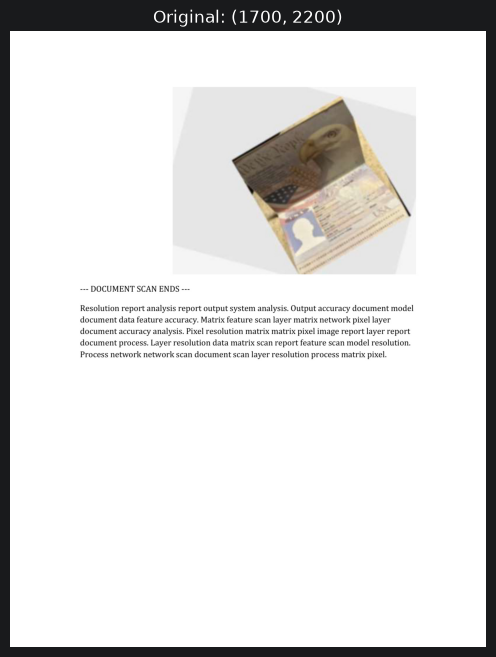

In [10]:
IMAGE_PATH = "./dataset_images/Word_Edge_Case_12_page_3.jpg"
results = predict_image(IMAGE_PATH)
display(results)

sample_image = open_rgb(IMAGE_PATH)

plt.figure(figsize=(8, 8))
plt.imshow(sample_image)
plt.title(f"Original: {sample_image.size}")
plt.axis("off")
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">דוגמה שניה - סיווג שונה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">התמונה השניה דומה מאוד לתמונה הקודמת                                     , גם דרכון גדול יחסית אבל ללא צבעים ונראה שמודל הרגרסיה נתן לה                                                                                              ציון של                                                                                                0.03                                                                                             מה שמצביע על זה המודל זה מאוד מושפע מצבע  ואילו מודל ה CNN אינו רגיש כולכך לתכונה זו ומתמודד מעולה עם דוגמאות מסוג זה.</div>
</div>

,model,prediction,passport_probability
0,Logistic Regression,No passport,0.033995
1,CNN,Passport,0.930789


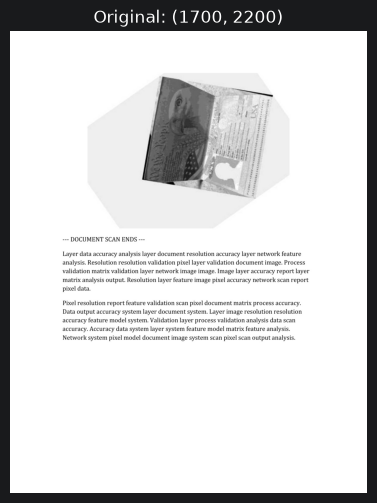

In [11]:
IMAGE_PATH = "./dataset_images/Word_Edge_Case_16_page_3.jpg"
results = predict_image(IMAGE_PATH)
display(results)

sample_image = open_rgb(IMAGE_PATH)

plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(f"Original: {sample_image.size}")
plt.axis("off")
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">דוגמה שלישית - סיווג שונה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">בדוגמה השלישית הציון של מודל הרגרסיה אף                                        נמוך יותר 0.01 למורת שהדרכון בתמונה צבעוני, ומכך אנו נסיק                                                                                               שהרגרסיה                                                                                                   מיחסת את כל החשיבות לצבע שמופיע בראש העמוד ומתעלמת לגמרי מתחתית העמוד. מנגד מודל ה CNN גם פה מציג           סיווג נכון עם ציון גבוהה משמע הוא אינו מתיחס למיקום הצבע בתמונה בצורה קיצונית כמו מודל                                                                                                הרגרסיה.</div>
</div>

,model,prediction,passport_probability
0,Logistic Regression,No passport,0.011898
1,CNN,Passport,0.829475


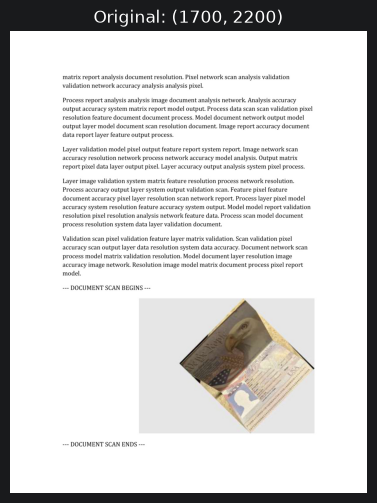

In [5]:
IMAGE_PATH = "./dataset_images/Word_Edge_Case_11_page_2.jpg"
results = predict_image(IMAGE_PATH)
display(results)

sample_image = open_rgb(IMAGE_PATH)

plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(f"Original: {sample_image.size}")
plt.axis("off")
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">דוגמה רביעית - סיווג שונה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">בתמונה שמוצגת בדוגמה האחרונה נראה שמודל                                        הרגרסיה אמנם גם טעה אבל הציון הוא הרבה יותר גבוהה 0.42 מה                                                                                               שמצביע                                                                                                 על                                                                                                 קח                                                                                                 שהתמונה שמכילה דרכון גדול הרבה יותר אבל בחלק התחתון של העמוד וגם מתקרב לאמצע העמוד היא ניית גבולית                                                                                                   בשביל מודל זה. תמונה זו חיזקה את המסכנות שלנו שמודל הרגרסיה רגיש מאוד לצבע בחלק בעליון בעמוד ומסווג כמאט אך ורק על פי זה ומנגד מודל הCNN מכליל מצויין ויודע להתמודד עם כל מיקום של הרדכון בדף ועם                                                         תמונות גם בשחור לבן.</div>
</div>

,model,prediction,passport_probability
0,Logistic Regression,No passport,0.425594
1,CNN,Passport,0.766055


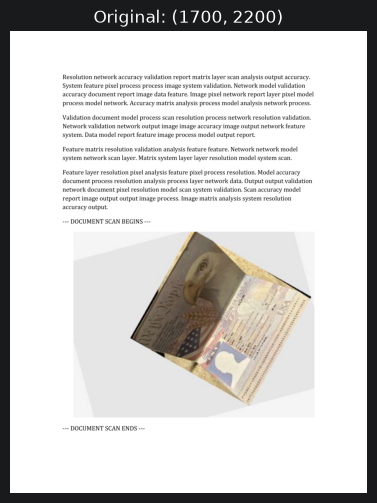

In [6]:
IMAGE_PATH = "./dataset_images/Word_Edge_Case_15_page_3.jpg"
results = predict_image(IMAGE_PATH)
display(results)

sample_image = open_rgb(IMAGE_PATH)

plt.figure(figsize=(6, 6))
plt.imshow(sample_image)
plt.title(f"Original: {sample_image.size}")
plt.axis("off")
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Models Benchmark</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; font-size: 1.5em; font-weight: 700; color: #2c3e50;">מסכנות</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">הרגרסיה מוכיחה את עצמה כמודל לא יעיל בסביבה אמיתית ומשמשת רק כנקודת התחלה להבנה שכדאי להמשיך עם היצוג הוקטורי שבחרנו. מצד שניה מודל                                                                                               הרשת                                                                                               שאימנו                                                                                                 מכליל מצויין ומסוגל להתמודד עם מקרי קצה שבהחלט יכולים להופיע בעולם האמיתי . מסכנה זו מובילה להבנה שמודל                                                                                                   זה למד במהלך האימון הקשרים מורכבים בין מאפינים שונים כמו צבעים צורות ומיקומם אחד ביחס לשני ולא                                                                                               רק דופוסים בסיסיים כמו צבע בלבד או מיקום פיקסלים בתמונה. </div>
</div>